**Run note:** execute this notebook's first setup/code cell before any later cells. Each notebook is designed to run independently and re-detect the dataset path on its own.

# 06 â€” Baseline Models

Builds and evaluates a ladder of baseline models to prove multimodal fusion adds value:
1. TF-IDF + Logistic Regression (text only)
2. BERT/RoBERTa classifier (text only)
3. CLIP image encoder + linear head (image only)
4. Concatenated CLIP embeddings + MLP (simple fusion)

Results from these baselines directly motivate the cross-attention architecture in notebook 07.

In [1]:
import os
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report

ON_KAGGLE = Path("/kaggle/input").is_dir()
JSONL_CANDIDATES = {
    "train": ["train.jsonl"],
    "dev": ["dev.jsonl", "dev_seen.jsonl", "dev_unseen.jsonl"],
    "test": ["test.jsonl", "test_seen.jsonl", "test_unseen.jsonl"],
}
IMAGE_DIR_CANDIDATES = ("img", "images")


def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)


def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)


def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES["train"])


def detect_data_dir():
    for env_name in ("KAGGLE_DATA_DIR", "META_HATEFUL_MEME_DATA_DIR"):
        env_dir = os.environ.get(env_name, "").strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f"env:{env_name}"

    kaggle_input = Path("/kaggle/input")
    default_candidate = kaggle_input / "meta-hateful-meme-detection" / "data"
    if _looks_like_dataset_root(default_candidate):
        return default_candidate, "default:/kaggle/input/meta-hateful-meme-detection/data"

    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob("train.jsonl")):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

        for candidate in sorted(kaggle_input.rglob("*")):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

    for candidate in (Path.cwd() / "data", Path.cwd().parent / "data", Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f"local:{candidate}"

    return None, "not-found"


def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None


DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR to the folder containing train.jsonl and img/."
    )

IMG_DIR = next((DATA_DIR / name for name in IMAGE_DIR_CANDIDATES if (DATA_DIR / name).is_dir()), None)
TRAIN_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["train"])
DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["dev"])
OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

if TRAIN_PATH is None or DEV_PATH is None:
    raise FileNotFoundError(f"Expected train/dev splits under {DATA_DIR}")

DATA_DIR = str(DATA_DIR)
IMG_DIR = str(IMG_DIR) if IMG_DIR is not None else None
TRAIN_PATH = str(TRAIN_PATH)
DEV_PATH = str(DEV_PATH)
OUTPUT_DIR = str(OUTPUT_DIR)

print(f"Using DATA_DIR : {DATA_DIR}")
print(f"Using IMG_DIR  : {IMG_DIR}")
print(f"Using source   : {data_source}")
print(f"Output dir     : {OUTPUT_DIR}")


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f])


def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    return re.sub(r"\s+", " ", text).strip()


train = load_jsonl(TRAIN_PATH)
dev = load_jsonl(DEV_PATH)
for df in [train, dev]:
    df["clean_text"] = df["text"].apply(clean_text).replace("", "[no text]").fillna("[no text]")

print(f"Train={len(train)}, Dev={len(dev)}")

Device: cuda
Using DATA_DIR : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Using IMG_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img
Using source   : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output dir     : /kaggle/working
Train=8500, Dev=500


In [2]:
from pathlib import Path


def resolve_image_path(data_dir, image_ref):
    data_dir = Path(data_dir)
    image_ref = Path(str(image_ref))

    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)

    candidates.extend([
        data_dir / image_ref,
        data_dir.parent / image_ref,
    ])

    if image_ref.parts:
        if image_ref.parts[0] in {"img", "images"} and len(image_ref.parts) > 1:
            stripped = Path(*image_ref.parts[1:])
            candidates.extend([
                data_dir / stripped,
                data_dir.parent / stripped,
            ])
        elif image_ref.parts[0] not in {"img", "images"}:
            candidates.extend([
                data_dir / "img" / image_ref,
                data_dir / "images" / image_ref,
                data_dir.parent / "img" / image_ref,
                data_dir.parent / "images" / image_ref,
            ])

    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find image '{image_ref}' relative to {data_dir}")

In [3]:
# â”€â”€ Helper: compute all metrics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def compute_metrics(labels, preds, probs, name=""):
    acc  = accuracy_score(labels, preds)
    f1_h = f1_score(labels, preds, pos_label=1)
    f1_m = f1_score(labels, preds, average="macro")
    auc  = roc_auc_score(labels, probs)
    print(f"  {name:30s}  Acc={acc:.3f}  F1(hate)={f1_h:.3f}  MacroF1={f1_m:.3f}  AUROC={auc:.3f}")
    return {"name": name, "accuracy": acc, "f1_hateful": f1_h,
            "macro_f1": f1_m, "auroc": auc}

all_results = []

In [4]:
# â”€â”€ Baseline 1: TF-IDF + Logistic Regression â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

tfidf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                               sublinear_tf=True, min_df=2)),
    ("clf",   LogisticRegression(C=1.0, max_iter=1000,
                                  class_weight="balanced", random_state=42)),
])

tfidf_pipe.fit(train["clean_text"], train["label"])
preds_tfidf = tfidf_pipe.predict(dev["clean_text"])
probs_tfidf = tfidf_pipe.predict_proba(dev["clean_text"])[:, 1]

r = compute_metrics(dev["label"], preds_tfidf, probs_tfidf, "1. TF-IDF + LR (text)")
all_results.append(r)

  1. TF-IDF + LR (text)           Acc=0.560  F1(hate)=0.463  MacroF1=0.545  AUROC=0.594


In [5]:
# â”€â”€ Baseline 2: RoBERTa text classifier â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.enc    = tokenizer(list(texts), padding="max_length", truncation=True,
                                max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()}, self.labels[i]

rob_tokenizer = AutoTokenizer.from_pretrained("roberta-base")
rob_model     = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
).to(DEVICE)

train_text_ds = TextDataset(train["clean_text"], train["label"],  rob_tokenizer)
dev_text_ds   = TextDataset(dev["clean_text"],   dev["label"],    rob_tokenizer)

train_loader = DataLoader(train_text_ds, batch_size=32, shuffle=True,  num_workers=2)
dev_loader   = DataLoader(dev_text_ds,   batch_size=64, shuffle=False, num_workers=2)

# Quick fine-tune: 3 epochs
optimizer = torch.optim.AdamW(rob_model.parameters(), lr=2e-5, weight_decay=0.01)
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler(enabled=(DEVICE=="cuda"))

rob_model.train()
for epoch in range(3):
    total_loss = 0
    for batch_enc, batch_labels in train_loader:
        optimizer.zero_grad()
        batch_enc   = {k: v.to(DEVICE) for k, v in batch_enc.items()}
        batch_labels = batch_labels.to(DEVICE)
        with autocast(enabled=(DEVICE=="cuda")):
            out  = rob_model(**batch_enc, labels=batch_labels)
        scaler.scale(out.loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += out.loss.item()
    print(f"  Epoch {epoch+1}/3  loss={total_loss/len(train_loader):.4f}")

# Evaluate
rob_model.eval()
all_probs, all_preds, all_labs = [], [], []
with torch.no_grad():
    for batch_enc, batch_labels in dev_loader:
        batch_enc = {k: v.to(DEVICE) for k, v in batch_enc.items()}
        logits    = rob_model(**batch_enc).logits
        probs     = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds     = logits.argmax(-1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labs.extend(batch_labels.numpy())

r = compute_metrics(all_labs, all_preds, all_probs, "2. RoBERTa (text only)")
all_results.append(r)

# Save checkpoint
torch.save(rob_model.state_dict(), os.path.join(OUTPUT_DIR, "roberta_text_only.pt"))

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_55/1274193231.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please us

  Epoch 1/3  loss=0.5934
  Epoch 2/3  loss=0.5280
  Epoch 3/3  loss=0.4870
  2. RoBERTa (text only)          Acc=0.548  F1(hate)=0.331  MacroF1=0.495  AUROC=0.645


In [6]:
#  Baseline 3: CLIP image-only linear probe 
from torch.utils.data import DataLoader, Dataset
from transformers import CLIPModel, CLIPProcessor

class ImageOnlyDataset(Dataset):
    def __init__(self, df, data_dir, processor):
        self.df        = df.reset_index(drop=True)
        self.data_dir  = data_dir
        self.processor = processor
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(resolve_image_path(self.data_dir, row["img"])).convert("RGB")
        except:
            img = Image.new("RGB", (224, 224), 128)
        enc = self.processor(images=img, return_tensors="pt")
        lbl = int(row["label"]) if "label" in row else -1
        return enc["pixel_values"].squeeze(0), torch.tensor(lbl, dtype=torch.long)

clip_base  = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def _ensure_tensor(out):
    """Extract tensor from model output if it returns a dataclass instead of a plain tensor."""
    if isinstance(out, torch.Tensor):
        return out
    if hasattr(out, "pooler_output") and out.pooler_output is not None:
        return out.pooler_output
    if hasattr(out, "last_hidden_state"):
        return out.last_hidden_state[:, 0]
    return out[0]

# Freeze CLIP
for p in clip_base.parameters():
    p.requires_grad_(False)

class ImageLinearHead(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip   = clip_model
        self.head   = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 2)
        )
    def forward(self, pixel_values):
        feats = _ensure_tensor(self.clip.get_image_features(pixel_values=pixel_values))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        return self.head(feats)

img_model = ImageLinearHead(clip_base).to(DEVICE)

img_train_ds = ImageOnlyDataset(train, DATA_DIR, clip_proc)
img_dev_ds   = ImageOnlyDataset(dev,   DATA_DIR, clip_proc)
img_train_loader = DataLoader(img_train_ds, batch_size=32, shuffle=True,  num_workers=2)
img_dev_loader   = DataLoader(img_dev_ds,   batch_size=64, shuffle=False, num_workers=2)

optimizer = torch.optim.AdamW(img_model.head.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.786]).to(DEVICE))

img_model.train()
for epoch in range(5):
    total_loss = 0
    for pixels, labels in img_train_loader:
        pixels, labels = pixels.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(img_model(pixels), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}/5  loss={total_loss/len(img_train_loader):.4f}")

img_model.eval()
all_probs, all_preds, all_labs = [], [], []
with torch.no_grad():
    for pixels, labels in img_dev_loader:
        pixels = pixels.to(DEVICE)
        logits = img_model(pixels)
        probs  = torch.softmax(logits, -1)[:, 1].cpu().numpy()
        preds  = logits.argmax(-1).cpu().numpy()
        all_probs.extend(probs); all_preds.extend(preds); all_labs.extend(labels.numpy())

r = compute_metrics(all_labs, all_preds, all_probs, "3. CLIP image + linear (img)")
all_results.append(r)
torch.save(img_model.state_dict(), os.path.join(OUTPUT_DIR, "clip_image_only.pt"))

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  Epoch 1/5  loss=0.6480
  Epoch 2/5  loss=0.6076
  Epoch 3/5  loss=0.5887
  Epoch 4/5  loss=0.5744
  Epoch 5/5  loss=0.5614
  3. CLIP image + linear (img)    Acc=0.564  F1(hate)=0.466  MacroF1=0.549  AUROC=0.647


In [7]:
#  Baseline 4: Simple CLIP concat fusion (text + image) 
from torch.utils.data import DataLoader, Dataset

class SimpleFusionDataset(Dataset):
    def __init__(self, df, data_dir, processor):
        self.df        = df.reset_index(drop=True)
        self.data_dir  = data_dir
        self.processor = processor
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(resolve_image_path(self.data_dir, row["img"])).convert("RGB")
        except:
            img = Image.new("RGB", (224, 224), 128)
        text = str(row.get("clean_text", row["text"]))
        enc  = self.processor(text=[text], images=img, return_tensors="pt",
                               padding="max_length", max_length=77, truncation=True)
        lbl  = int(row["label"]) if "label" in row else -1
        return (
            enc["pixel_values"].squeeze(0),
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            torch.tensor(lbl, dtype=torch.long),
        )

class SimpleFusionHead(nn.Module):
    def __init__(self, clip_model, embed_dim=512):
        super().__init__()
        self.clip = clip_model
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 2)
        )
    def forward(self, pixel_values, input_ids, attention_mask):
        img_feat = _ensure_tensor(self.clip.get_image_features(pixel_values=pixel_values))
        txt_feat = _ensure_tensor(self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask))
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
        fused = torch.cat([img_feat, txt_feat], dim=-1)
        return self.classifier(fused)

fusion_model = SimpleFusionHead(clip_base).to(DEVICE)
optimizer = torch.optim.AdamW(fusion_model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 1.786]).to(DEVICE))

fusion_train_ds = SimpleFusionDataset(train, DATA_DIR, clip_proc)
fusion_dev_ds   = SimpleFusionDataset(dev,   DATA_DIR, clip_proc)
fusion_train_loader = DataLoader(fusion_train_ds, batch_size=32, shuffle=True,  num_workers=2)
fusion_dev_loader   = DataLoader(fusion_dev_ds,   batch_size=64, shuffle=False, num_workers=2)

fusion_model.train()
for epoch in range(5):
    total_loss = 0
    for pixels, ids, mask, labels in fusion_train_loader:
        pixels, ids, mask, labels = pixels.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(fusion_model(pixels, ids, mask), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}/5  loss={total_loss/len(fusion_train_loader):.4f}")

fusion_model.eval()
all_probs, all_preds, all_labs = [], [], []
with torch.no_grad():
    for pixels, ids, mask, labels in fusion_dev_loader:
        pixels, ids, mask = pixels.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE)
        logits = fusion_model(pixels, ids, mask)
        probs  = torch.softmax(logits, -1)[:, 1].cpu().numpy()
        preds  = logits.argmax(-1).cpu().numpy()
        all_probs.extend(probs); all_preds.extend(preds); all_labs.extend(labels.numpy())

r = compute_metrics(all_labs, all_preds, all_probs, "4. CLIP simple concat fusion")
all_results.append(r)
torch.save(fusion_model.state_dict(), os.path.join(OUTPUT_DIR, "clip_simple_fusion.pt"))

  Epoch 1/5  loss=0.6109
  Epoch 2/5  loss=0.5405
  Epoch 3/5  loss=0.5113
  Epoch 4/5  loss=0.4825
  Epoch 5/5  loss=0.4610
  4. CLIP simple concat fusion    Acc=0.634  F1(hate)=0.583  MacroF1=0.628  AUROC=0.700



BASELINE COMPARISON TABLE
                        name  accuracy  f1_hateful  macro_f1  auroc
       1. TF-IDF + LR (text)     0.560       0.463     0.545  0.594
      2. RoBERTa (text only)     0.548       0.331     0.495  0.645
3. CLIP image + linear (img)     0.564       0.466     0.549  0.647
4. CLIP simple concat fusion     0.634       0.583     0.628  0.700


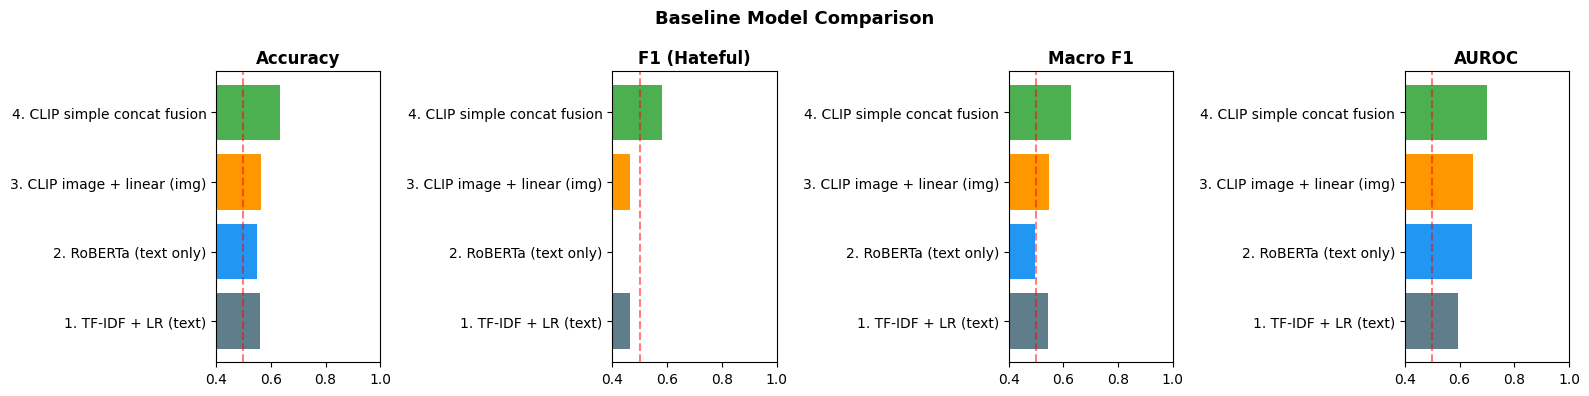


Baselines complete. Proceed to notebook 07 (Main Model).


In [8]:
# â”€â”€ Baseline Summary Table â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
results_df = pd.DataFrame(all_results)
print("\n" + "=" * 75)
print("BASELINE COMPARISON TABLE")
print("=" * 75)
print(results_df.to_string(index=False, float_format="{:.3f}".format))

# Plot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ["accuracy", "f1_hateful", "macro_f1", "auroc"]
titles  = ["Accuracy", "F1 (Hateful)", "Macro F1", "AUROC"]

for ax, metric, title in zip(axes, metrics, titles):
    ax.barh(results_df["name"], results_df[metric],
            color=["#607D8B", "#2196F3", "#FF9800", "#4CAF50"])
    ax.set_xlim(0.4, 1.0)
    ax.set_title(title, fontweight="bold")
    ax.axvline(0.5, linestyle="--", color="red", alpha=0.5)

plt.suptitle("Baseline Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
results_df.to_csv(os.path.join(OUTPUT_DIR, "baseline_results.csv"), index=False)
print("\nBaselines complete. Proceed to notebook 07 (Main Model).")